In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = h5py.File("event_93970574.h5")
list(f.keys())

['positions', 'times', 'traces']

In [3]:
traces = f["traces"]
traces.shape

(14, 96, 2, 65536)

In [4]:
data = traces
# 1. Check for completely zero or flat traces (Variance = 0)
# Compute variance over the trace axis (axis 3) and polarization axis (axis 2)
trace_variance = np.var(data, axis=(2, 3))  # Result shape: (14, 96)

# 2. Check for NaN (Not a Number) values if data was corrupted
is_nan_mask = np.isnan(data).all(axis=(2, 3))  # Result shape: (14, 96)

# 3. Find active stations and channels
# A slice is "active" if it has variance greater than 0 and is not all NaNs
active_mask = (trace_variance > 0) & (~is_nan_mask)

# 4. Print the active counts
print(f"Total active station/channel combinations: {np.sum(active_mask)} out of 1344")

# List exactly which stations have at least one active channel
active_stations = np.where(active_mask.any(axis=1))[0]
print(f"Active station indices: {active_stations} (Total: {len(active_stations)})")

# List exactly which channels have at least one active station
active_channels = np.where(active_mask.any(axis=0))[0]
print(f"Active channel indices: {active_channels} (Total: {len(active_channels)})")

Total active station/channel combinations: 1224 out of 1344
Active station indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13] (Total: 14)
Active channel indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93] (Total: 94)


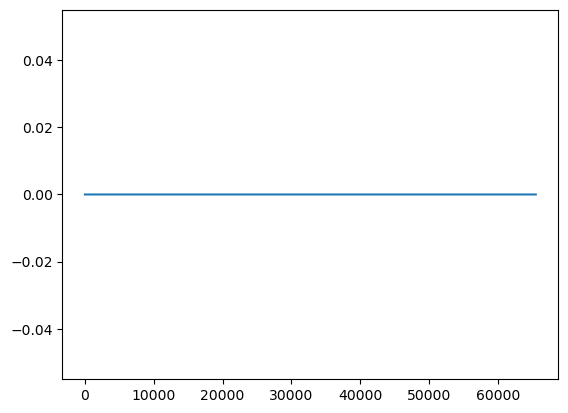

In [13]:
plt.plot(traces[12,94,1])
plt.show()